In [2]:
# ==============================================
# 📦 IMPORTS
# ==============================================
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [3]:
import os
import cv2
import numpy as np

labels = ['PNEUMONIA', 'NORMAL']
img_size = 150

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img}: {e}")
    return data  # ✅ return list (not np.array)

# ✅ Load datasets
train = get_data(r'E:/clg/archive/chest_xray/chest_xray/train')
test = get_data(r'E:/clg/archive/chest_xray/chest_xray/test')
val = get_data(r'E:/clg/archive/chest_xray/chest_xray/val')

# ✅ Split features and labels
x_train, y_train = [], []
x_val, y_val = [], []
x_test, y_test = [], []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

# ✅ Convert to numpy arrays and normalize
x_train = np.array(x_train) / 255.0
x_val = np.array(x_val) / 255.0
x_test = np.array(x_test) / 255.0

# ✅ Add channel dimension (since grayscale)
x_train = x_train.reshape(-1, img_size, img_size, 1)
x_val = x_val.reshape(-1, img_size, img_size, 1)
x_test = x_test.reshape(-1, img_size, img_size, 1)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("✅ Data Loaded Successfully!")
print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)


Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

✅ Data Loaded Successfully!
Train: (5216, 150, 150, 1)
Validation: (16, 150, 150, 1)
Test: (624, 150, 150, 1)


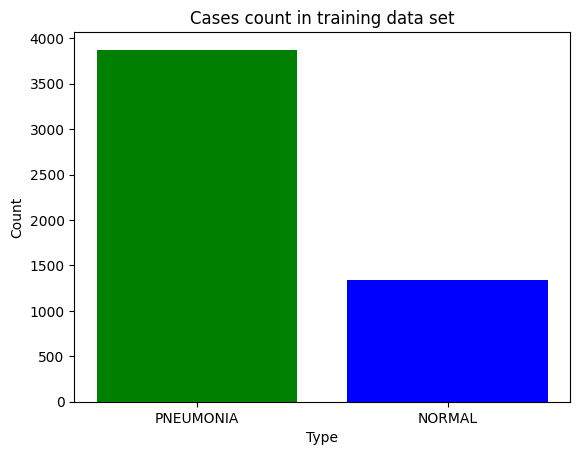

In [4]:
positives = []
negatives = []

for i in range(len(y_train)):
    if y_train[i]:
        positives.append(x_train[i])
    else:
        negatives.append(x_train[i])

plt.bar(labels, [len(negatives), len(positives)], color=["green", "blue"])
plt.title("Cases count in training data set")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


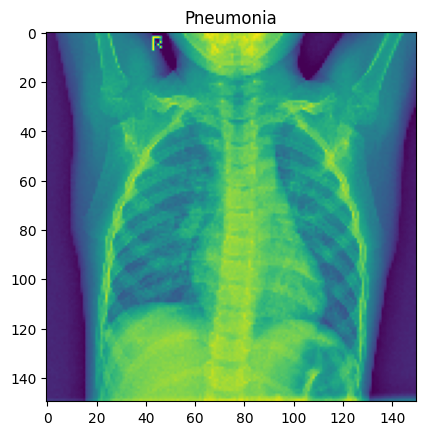

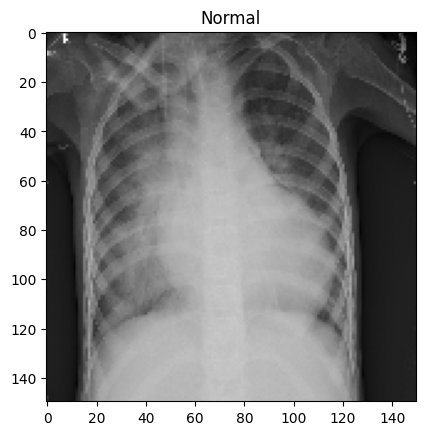

In [5]:
plt.imshow(positives[0])
plt.title("Pneumonia")
plt.show()

plt.imshow(negatives[4], cmap="gray")
plt.title("Normal")
plt.show()


In [6]:
# -------------------------------------------------
# 2. Define paths (add these two lines)
# -------------------------------------------------
train_path = r'E:/clg/archive/chest_xray/chest_xray/train'
test_path  = r'E:/clg/archive/chest_xray/chest_xray/test'

# -------------------------------------------------
# 3. Data generators (your original code – now works)
# -------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.25,
    height_shift_range=0.25,
    zoom_range=0.25,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
# ==============================================
# ⚖️ CLASS WEIGHT (Handle Imbalance)
# ==============================================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))
print("\nCalculated Class Weights:", class_weights)



Calculated Class Weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [8]:
# ==============================================
# 🧠 BUILD TRANSFER LEARNING MODEL (VGG16)
# ==============================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers for initial training
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,691,841 (105.64 MB)

 Trainable params: 12,977,153 (49.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
# ==============================================
# 🧩 CALLBACKS
# ==============================================
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]


In [10]:
# ==============================================
# 🚀 TRAIN MODEL
# ==============================================
history = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


C:\Users\tiken\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 402s 3s/step - accuracy: 0.7355 - loss: 0.5452 - precision: 0.8984 - recall: 0.7289 - val_accuracy: 0.8830 - val_loss: 0.2582 - val_precision: 0.9910 - val_recall: 0.8503 - learning_rate: 1.0000e-04
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.8715 - loss: 0.3028 - precision: 0.9590 - recall: 0.8659 - val_accuracy: 0.8399 - val_loss: 0.3649 - val_precision: 0.9984 - val_recall: 0.7858 - learning_rate: 1.0000e-04
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.8771 - loss: 0.2726 - precision: 0.9686 - recall: 0.8613 - val_accuracy: 0.8130 - val_loss: 0.4251 - val_precision: 1.0000 - val_recall: 0.7484 - learning_rate: 1.0000e-04
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.8782 - loss: 0.2622 - precision: 0.9676 - recall: 0.8633 - val_accuracy: 0.9233 - val_loss: 0.1788 - val_precision: 0.9754 - val_recall: 0.9200 - learning_rate: 1.0000e-04
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 372s

In [11]:
# ==============================================
# 🧾 EVALUATE MODEL
# ==============================================
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f} | Precision: {test_prec:.4f} | Recall: {test_rec:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8843 - loss: 0.2750 - precision: 0.5236 - recall: 0.6342

✅ Test Accuracy: 0.9054 | Precision: 0.9046 | Recall: 0.9487


In [12]:
# ==============================================
# 💾 SAVE MODEL
# ==============================================
os.makedirs("models", exist_ok=True)
model.save("models/vgg16_pneumonia_model.h5")
print("✅ Model saved to models/vgg16_pneumonia_model.h5")


✅ Model saved to models/vgg16_pneumonia_model.h5


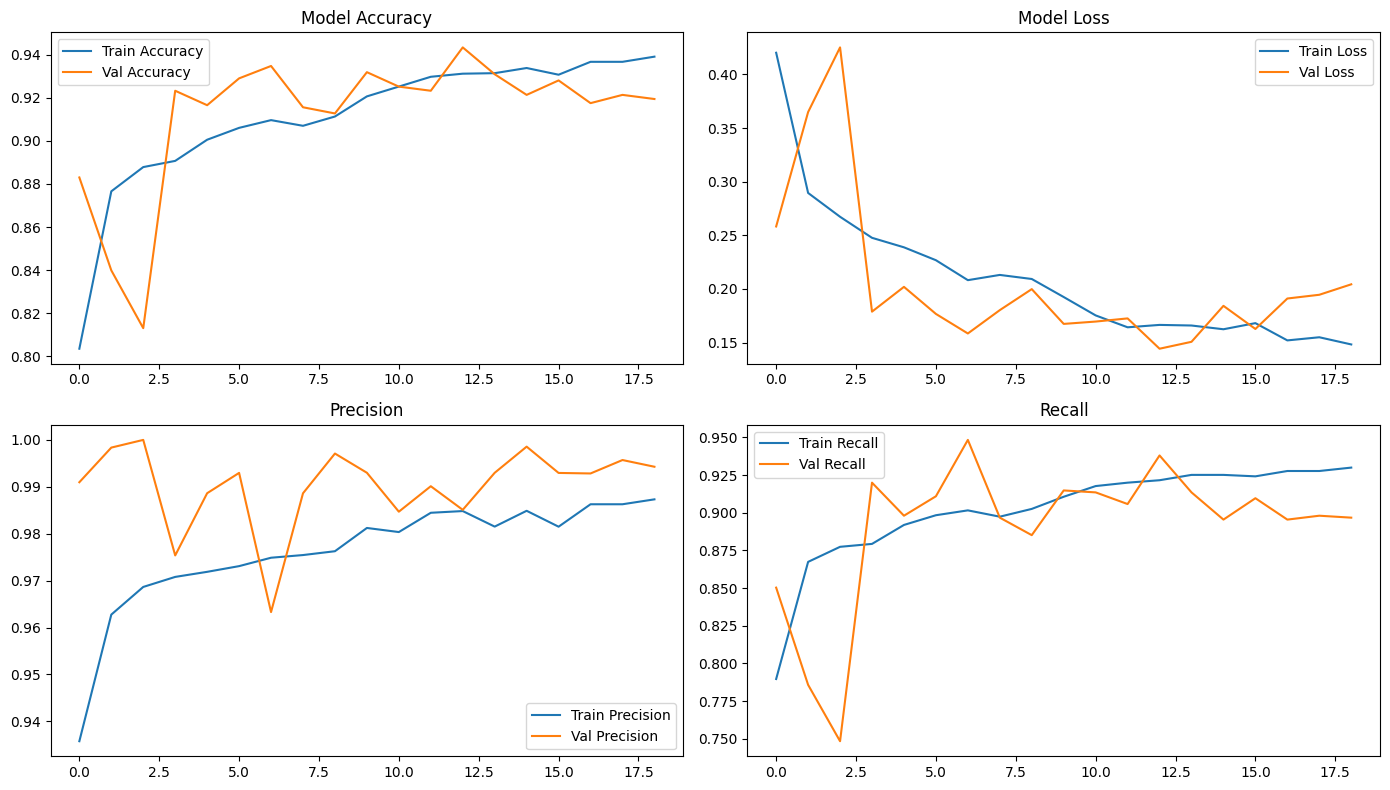

In [13]:
# ==============================================
# 📊 PLOT TRAINING HISTORY
# ==============================================
plt.figure(figsize=(14, 8))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')

# Precision
plt.subplot(2, 2, 3)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.legend()
plt.title('Precision')

# Recall
plt.subplot(2, 2, 4)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.legend()
plt.title('Recall')

plt.tight_layout()
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step


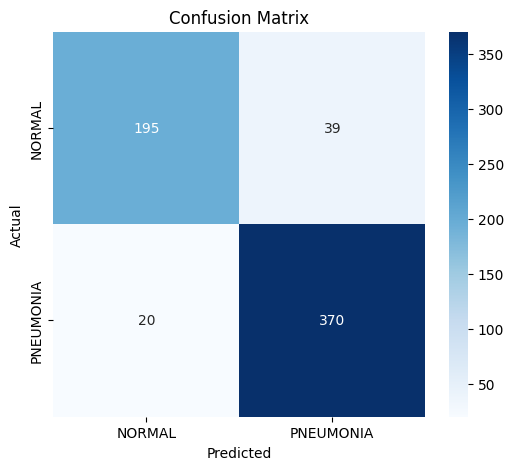


Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.91      0.83      0.87       234
   PNEUMONIA       0.90      0.95      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.90       624



In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, test_gen):
    # predict and flatten to 1D
    y_pred = (model.predict(test_gen) > 0.5).astype("int32").ravel()
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    labels = list(test_gen.class_indices.keys())

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=labels))

# use the existing 'model' variable (detector is not defined)
evaluate_model(model, test_gen)


In [ ]:
# ==============================================
# 🔓 FINE-TUNE LAST FEW LAYERS FOR HIGHER ACCURACY
# ==============================================
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    verbose=1
)

# Final evaluation
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_gen)
print(f"\n🏆 Final Test Accuracy: {test_acc:.4f} | Precision: {test_prec:.4f} | Recall: {test_rec:.4f}")


NameError: name 'base_model' is not defined

: 

In [ ]:
# Add this to last cell of your 8.ipynb
model.save('pneumonia_model.h5')
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
# Note: `tensorflow` (tf) is already imported earlier in the notebook.
# If not, uncomment the next line:
# import tensorflow as tf

# If your saved model used a custom preprocessing function like `grayscale_to_rgb`,
# Keras needs to know about it when loading. Register it so load_model can find it.
@tf.keras.utils.register_keras_serializable()
def grayscale_to_rgb(x):
    # expects a [B,H,W,1] grayscale tensor -> returns [B,H,W,3]
    return tf.image.grayscale_to_rgb(x)

# Saved Keras model ko load karo (disable compile if you don't need optimizer state)
model = tf.keras.models.load_model('pneumonia_model.h5', compile=False)

# TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional but highly recommended for Flutter (4x chhota model + tez chalta hai)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# If you need to allow select TF ops (only if converter errors about unsupported ops)
# converter.target_spec.supported_ops = [
#     tf.lite.OpsSet.TFLITE_BUILTINS,
#     tf.lite.OpsSet.SELECT_TF_OPS
# ]

# Convert karo
tflite_model = converter.convert()

# Save karo sahi naam se
with open('pneumonia_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Pneumonia model successfully converted & saved as pneumonia_model.tflite")
print(f"Size: {len(tflite_model) / (1024*1024):.2f} MB")

NameError: name 'tf' is not defined